# Final Analysis – ADHD Representation on TikTok
Quantitative Content Analysis

- **RQ1** Which general content characteristics can be identified in ADHD-related TikTok videos?
- **RQ2** To what extent are everyday experiences linked to ADHD, and are they framed as symptoms or signs of ADHD?
- **RQ3** Which sources of knowledge are referenced when ADHD is portrayed?
- **RQ4** Which patterns of co-occurrence can be identified among the content features?

In [1]:
# ── Settings ──────────────────────────────────────────────────
FINAL_CSV  = "../data/final_coding_sheet.csv"
EXPORT_PNG = False  # True = save all figures as PNG
DPI        = 300

In [2]:
# ── Import Packages & Style ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact

sns.set_theme(style="white", font="DejaVu Sans")

# Wong colorblind-safe palette (recommended by Nature)
PALETTE = {"RQ1": "#0072B2", "RQ2": "#009E73", "RQ3": "#D55E00", "RQ4": "#CC79A7"}
CB_REGION = ["#0072B2", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
CB_SEQ = "crest"

plt.rcParams.update({
    "figure.dpi"       : 150,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
})

def save(name):
    if EXPORT_PNG:
        path = f"{name}.png"
        plt.savefig(path, dpi=DPI, bbox_inches="tight", facecolor="white")
        print(f"  Saved -> {path}")

print("Setup complete.")

Setup complete.


In [3]:
# ── Load Data ─────────────────────────────────────────────────
df_all = pd.read_csv(FINAL_CSV)

# Variable definitions
RQ1 = ["personal_narrative", "explanatory_elements", "advice_coping",
       "performed_scenario", "emotional_expressions"]
RQ2 = ["everyday_experience_present", "everyday_experience_linked_to_ADHD",
       "experience_as_symptom_sign_framing", "clinical_or_diagnostic_language",
       "demedicalization_framing"]
RQ3 = ["lived_experience_source", "professional_expertise_source",
       "scientific_or_medical_source", "community_or_platform_source"]
ALL_VARS = RQ1 + RQ2 + RQ3

SHORT = {
    "personal_narrative": "Personal narrative",
    "explanatory_elements": "Explanatory elements",
    "advice_coping": "Advice / coping",
    "performed_scenario": "Performed scenario",
    "emotional_expressions": "Emotional expression",
    "everyday_experience_present": "Ev. experience present",
    "everyday_experience_linked_to_ADHD": "Ev. linked to ADHD",
    "experience_as_symptom_sign_framing": "Symptom / sign framing",
    "clinical_or_diagnostic_language": "Clinical language",
    "demedicalization_framing": "Demedicalization framing",
    "lived_experience_source": "Lived experience",
    "professional_expertise_source": "Professional expertise",
    "scientific_or_medical_source": "Scientific / medical",
    "community_or_platform_source": "Community / platform"
}

# Filter relevant videos only
df = df_all[df_all["relevant"] == 1].copy()
df[ALL_VARS] = df[ALL_VARS].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)
N = len(df)

print(f"Total videos sampled: {len(df_all)}")
print(f"Relevant (included):  {N}")
print(f"Excluded:             {len(df_all) - N}")

Total videos sampled: 400
Relevant (included):  149
Excluded:             251


## 5.1 Descriptive Overview

In [4]:
# ── Sample Characteristics ─────────────────────────────────────
n_creators = df["username"].nunique()
print(df_all["relevant"].value_counts())
print(f"Final sample: n = {N} videos")
print(f"Unique creators: {n_creators}")
print(f"\nRegion distribution:")
print(df["region_code"].str.upper().value_counts())
print(f"\nView count:")
print(f"  Min:    {df['view_count'].min():>10,}")
print(f"  Median: {df['view_count'].median():>10,.0f}")
print(f"  Mean:   {df['view_count'].mean():>10,.0f}")
print(f"  Max:    {df['view_count'].max():>10,}")

relevant
0.0    247
1.0    149
Name: count, dtype: int64
Final sample: n = 149 videos
Unique creators: 130

Region distribution:
region_code
US    99
GB    45
AU     5
Name: count, dtype: int64

View count:
  Min:        10,022
  Median:     34,451
  Mean:      107,170
  Max:     3,917,740


**Note:** The following cells (Sample Characteristics, Region Distribution, and View Count Distribution) use `region_code` and `view_count` columns, which have been anonymized in the published dataset to comply with the TikTok Research API terms of service. Re-running these cells will therefore not reproduce the outputs shown below.

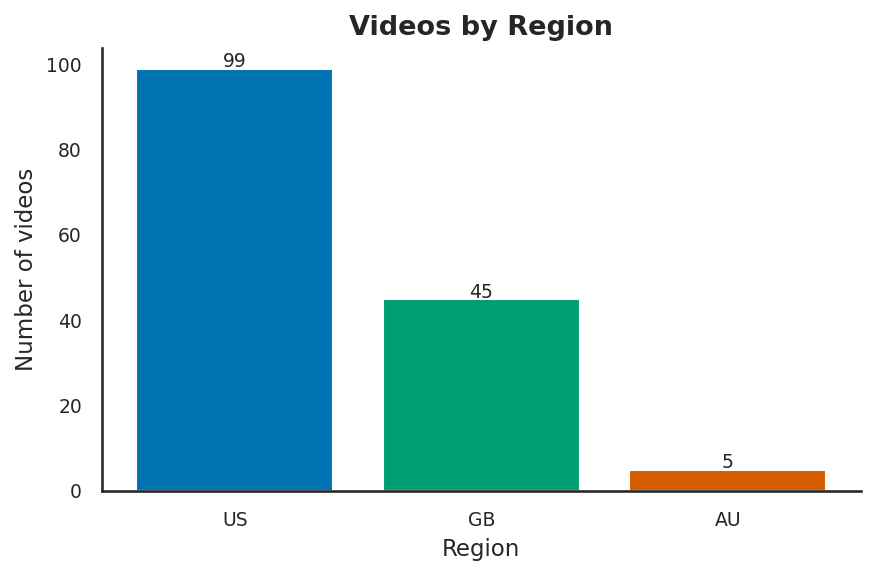

In [5]:
# ── Region Distribution ───────────────────────────────────────
region_counts = df["region_code"].str.upper().value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(region_counts.index, region_counts.values,
              color=CB_REGION[:len(region_counts)], edgecolor="white")
ax.set_xlabel("Region")
ax.set_ylabel("Number of videos")
ax.set_title("Videos by Region")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            int(bar.get_height()), ha="center", fontsize=9)
plt.tight_layout()
save("region_distribution")
plt.show()

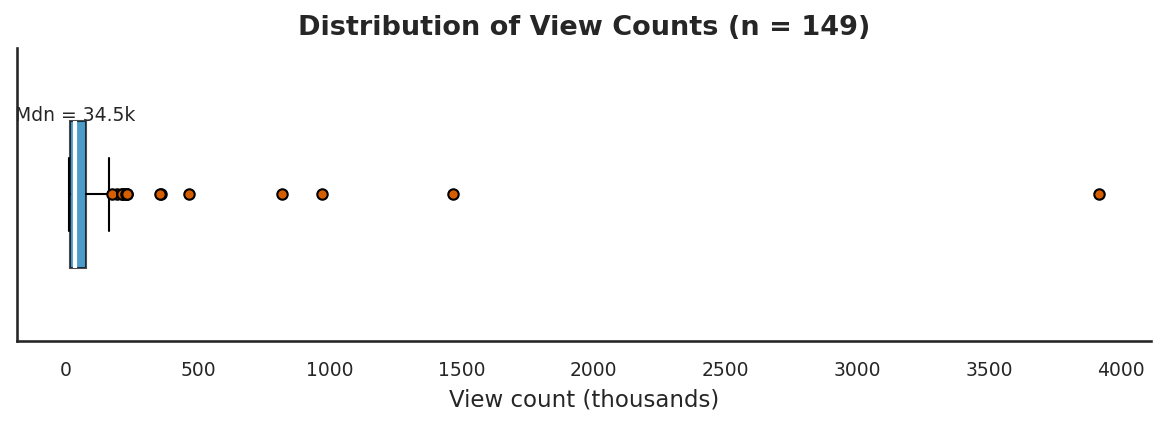

View count statistics:
  Min:        10,022
  Q1:         14,928
  Median:     34,451
  Mean:      107,170
  Q3:         77,266
  Max:     3,917,740
  SD:        355,496


In [6]:
 # ── View Count Distribution ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))      
bp = ax.boxplot(df["view_count"] / 1000, vert=False, widths=0.5, patch_artist=True,
   boxprops=dict(facecolor=PALETTE["RQ1"], alpha=0.7),                               
medianprops=dict(color="white", linewidth=2), flierprops=dict(marker="o",          
markerfacecolor="#D55E00", markersize=5))                                          
ax.set_xlabel("View count (thousands)")                                            
ax.set_yticks([])                                         
ax.set_title(f"Distribution of View Counts (n = {N})")                             
mdn = df["view_count"].median() / 1000                    
ax.text(mdn, 1.25, f"Mdn = {mdn:.1f}k", ha="center", fontsize=9)
plt.tight_layout()                      
fig.savefig("view_count_distribution.pdf", bbox_inches="tight", facecolor="white")
plt.show()   
                                                                                    
print(f"View count statistics:")                                                   
print(f"  Min:    {df['view_count'].min():>10,}")                                  
print(f"  Q1:     {df['view_count'].quantile(0.25):>10,.0f}")                      
print(f"  Median: {df['view_count'].median():>10,.0f}")                            
print(f"  Mean:   {df['view_count'].mean():>10,.0f}")                              
print(f"  Q3:     {df['view_count'].quantile(0.75):>10,.0f}")                      
print(f"  Max:    {df['view_count'].max():>10,}")                                  
print(f"  SD:     {df['view_count'].std():>10,.0f}")                               
                                                         

In [7]:
# ── Descriptive Statistics – All Variables ────────────────────
rows = []
for rq, varlist in [("RQ1", RQ1), ("RQ2", RQ2), ("RQ3", RQ3)]:
    for v in varlist:
        rows.append({
            "RQ": rq,
            "Variable": SHORT[v],
            "Present (n)": int(df[v].sum()),
            "Present (%)": f"{df[v].mean()*100:.1f}%"
        })
overview = pd.DataFrame(rows)
display(overview)

,RQ,Variable,Present (n),Present (%)
0,RQ1,Personal narrative,31,20.8%
1,RQ1,Explanatory elements,44,29.5%
2,RQ1,Advice / coping,41,27.5%
3,RQ1,Performed scenario,62,41.6%
4,RQ1,Emotional expression,11,7.4%
5,RQ2,Ev. experience present,130,87.2%
6,RQ2,Ev. linked to ADHD,128,85.9%
7,RQ2,Symptom / sign framing,4,2.7%
8,RQ2,Clinical language,54,36.2%
9,RQ2,Demedicalization framing,4,2.7%


## 5.2 RQ1 – Content Formats

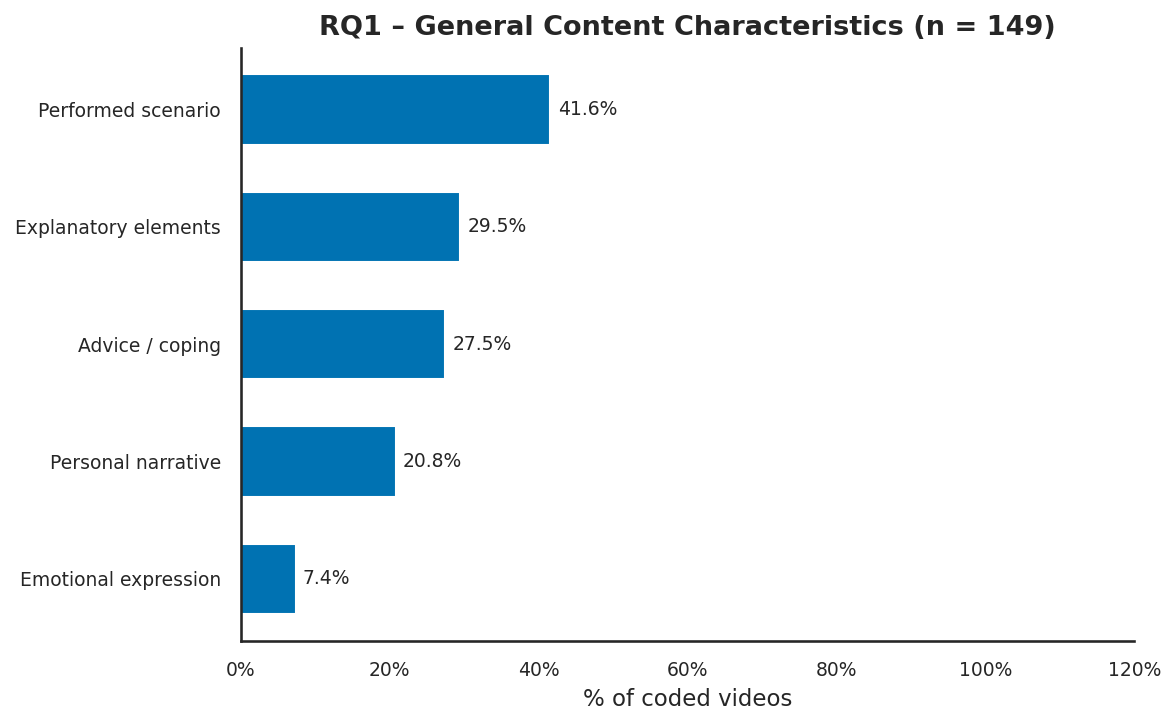

In [8]:
# ── RQ1: Content Characteristics ──────────────────────────────
vals = df[RQ1].mean() * 100
vals = vals.sort_values(ascending=True)
labs = [SHORT[v] for v in vals.index]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(labs, vals.values, color=PALETTE["RQ1"], edgecolor="white", height=0.6)
ax.set_xlim(0, 120)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("% of coded videos")
ax.set_title(f"RQ1 – General Content Characteristics (n = {N})")
for bar, val in zip(bars, vals.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
save("rq1_content_characteristics")
plt.show()

## 5.3 RQ2 – Everyday Experience & Framing

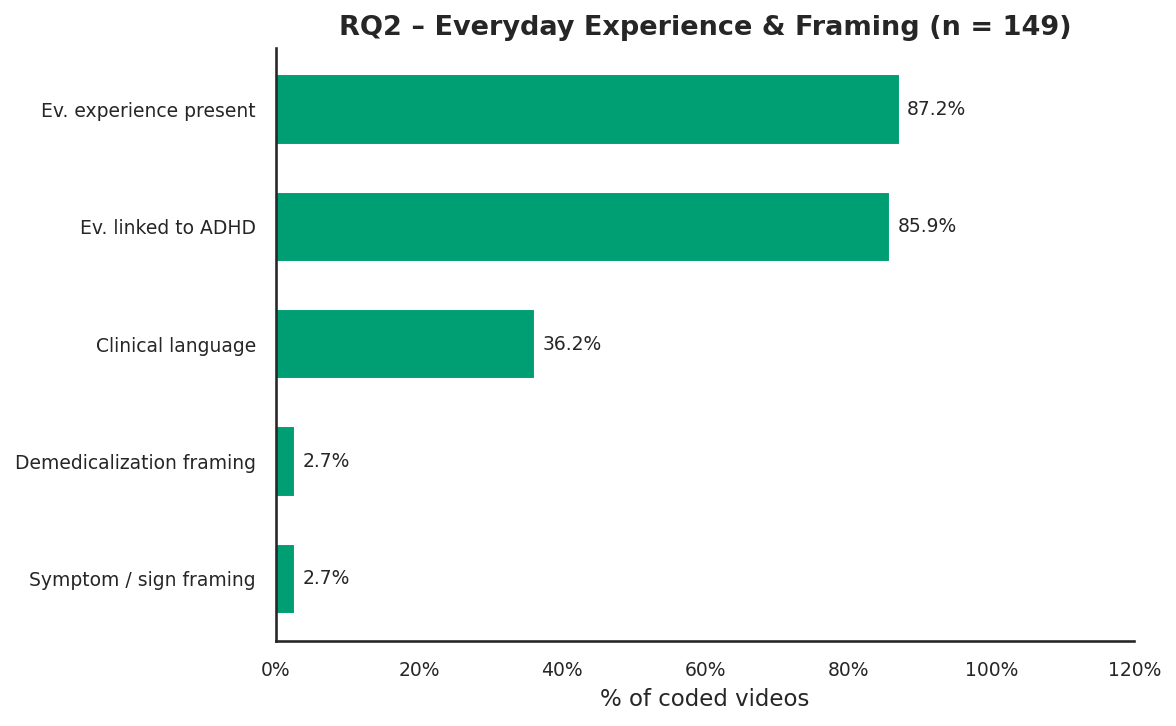

In [9]:
# ── RQ2: Everyday Experience Framing ──────────────────────────
vals = df[RQ2].mean() * 100
vals = vals.sort_values(ascending=True)
labs = [SHORT[v] for v in vals.index]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(labs, vals.values, color=PALETTE["RQ2"], edgecolor="white", height=0.6)
ax.set_xlim(0, 120)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("% of coded videos")
ax.set_title(f"RQ2 – Everyday Experience & Framing (n = {N})")
for bar, val in zip(bars, vals.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
save("rq2_everyday_experience")
plt.show()

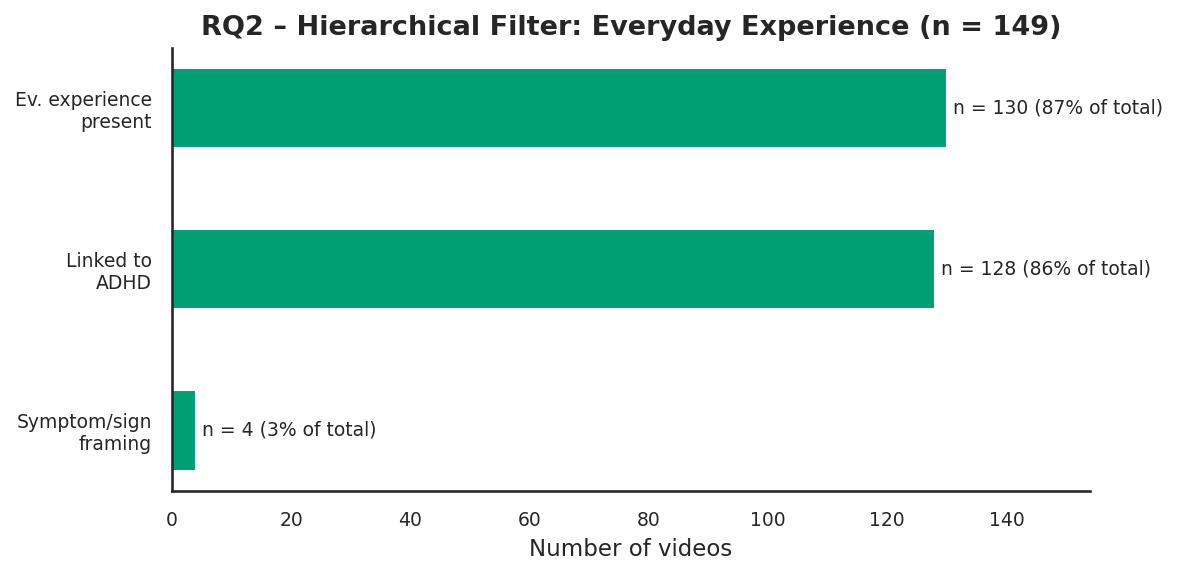

In [10]:
# ── RQ2: Hierarchical Filter Logic (Funnel) ───────────────────
n_present = int(df["everyday_experience_present"].sum())
n_linked  = int(df["everyday_experience_linked_to_ADHD"].sum())
n_framed  = int(df["experience_as_symptom_sign_framing"].sum())

stages = ["Ev. experience\npresent", "Linked to\nADHD", "Symptom/sign\nframing"]
counts = [n_present, n_linked, n_framed]
pcts_of_total = [c / N * 100 for c in counts]
pcts_of_prev  = [100,
                 n_linked / n_present * 100 if n_present > 0 else 0,
                 n_framed / n_linked * 100 if n_linked > 0 else 0]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(stages[::-1], counts[::-1], color=[PALETTE["RQ2"]]*3,
               edgecolor="white", height=0.5)
ax.set_xlabel("Number of videos")
ax.set_xlim(0, N + 5)  
ax.set_title(f"RQ2 – Hierarchical Filter: Everyday Experience (n = {N})")
for bar, c, pct_t, pct_p in zip(bars, counts[::-1], pcts_of_total[::-1], pcts_of_prev[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"n = {c} ({pct_t:.0f}% of total)",
            va="center", fontsize=9)
plt.tight_layout()
save("rq2_funnel")
plt.show()

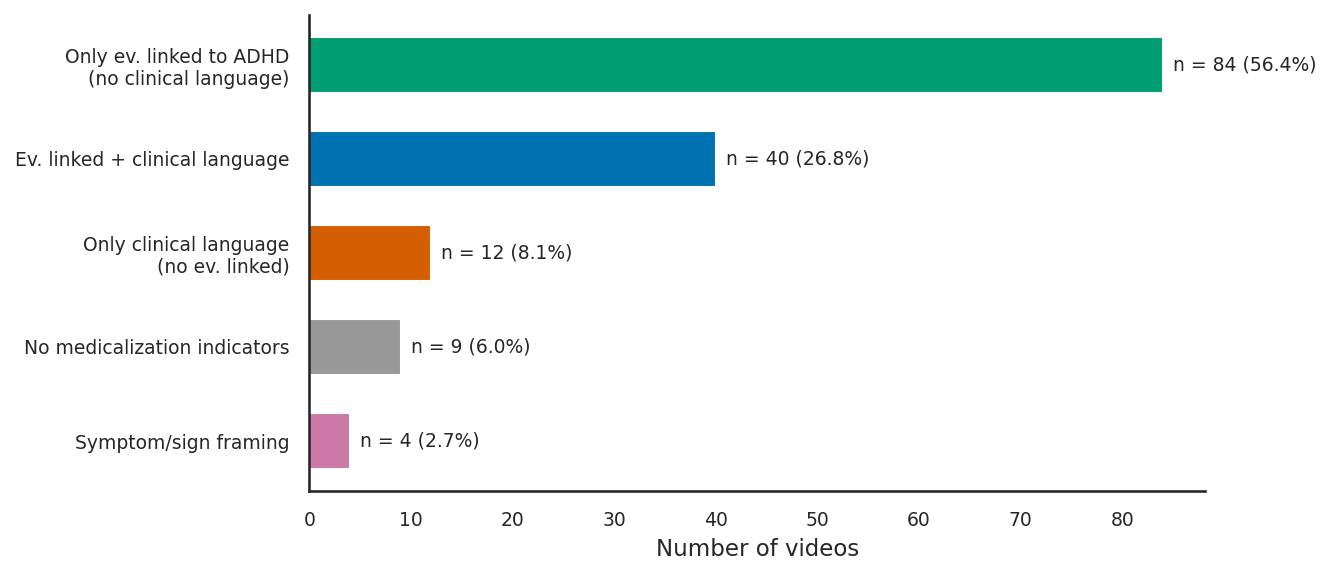

In [11]:
# ── RQ2: Medicalization Levels ─────────────────────────────────
no_med = ((df['everyday_experience_linked_to_ADHD']==0) & (df['clinical_or_diagnostic_language']==0)).sum()
only_linked = ((df['everyday_experience_linked_to_ADHD']==1) & (df['clinical_or_diagnostic_language']==0) & (df['experience_as_symptom_sign_framing']==0)).sum()
linked_plus_clinical = ((df['everyday_experience_linked_to_ADHD']==1) & (df['clinical_or_diagnostic_language']==1) & (df['experience_as_symptom_sign_framing']==0)).sum()
only_clinical = ((df['clinical_or_diagnostic_language']==1) & (df['everyday_experience_linked_to_ADHD']==0)).sum()
symptom = (df['experience_as_symptom_sign_framing']==1).sum()

labels = [
    f"Only ev. linked to ADHD\n(no clinical language)",
    f"Ev. linked + clinical language",
    f"Only clinical language\n(no ev. linked)",
    f"No medicalization indicators",
    f"Symptom/sign framing",
]
values = [only_linked, linked_plus_clinical, only_clinical, no_med, symptom]
pcts = [v / N * 100 for v in values]

colors = ["#009E73", "#0072B2", "#D55E00", "#999999", "#CC79A7"]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(range(len(labels)), values, color=colors, edgecolor="white", height=0.6)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Number of videos")
for bar, val, pct in zip(bars, values, pcts):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f"n = {val} ({pct:.1f}%)", va="center", fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
fig.savefig("medicalization_levels.pdf", bbox_inches="tight", facecolor="white")
plt.show()

## 5.4 RQ3 – Sources of Knowledge

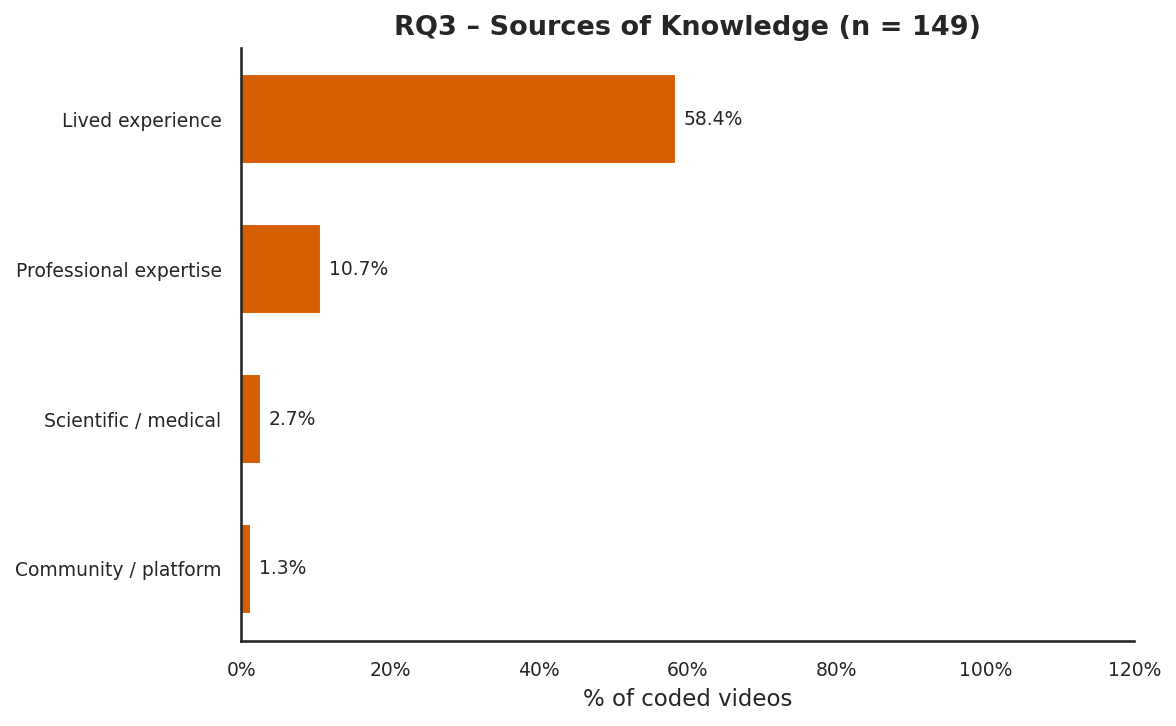

In [12]:
# ── RQ3: Sources of Knowledge ─────────────────────────────────
vals = df[RQ3].mean() * 100
vals = vals.sort_values(ascending=True)
labs = [SHORT[v] for v in vals.index]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(labs, vals.values, color=PALETTE["RQ3"], edgecolor="white", height=0.6)
ax.set_xlim(0, 120)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("% of coded videos")
ax.set_title(f"RQ3 – Sources of Knowledge (n = {N})")
for bar, val in zip(bars, vals.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
save("rq3_sources_of_knowledge")
plt.show()

## 5.5 RQ4 – Co-occurrence Patterns

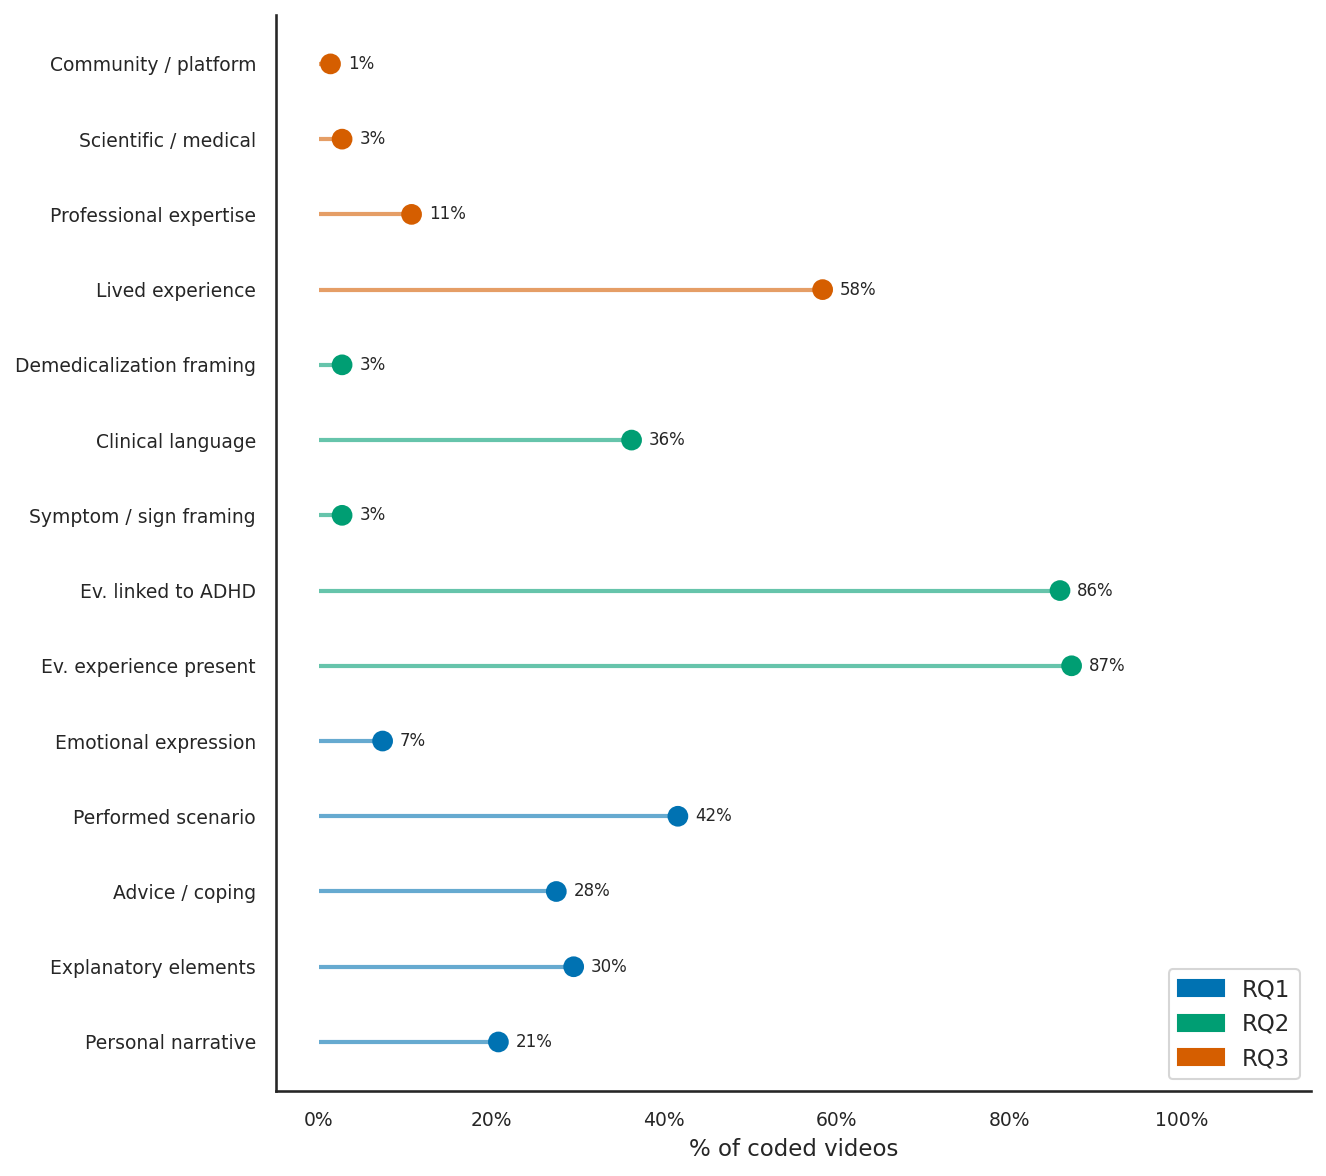

In [13]:
# ── All Variables Overview (Lollipop) ─────────────────────────
pct = df[ALL_VARS].mean() * 100
labels = [SHORT[v] for v in ALL_VARS]
colors = ([PALETTE["RQ1"]] * len(RQ1) +
          [PALETTE["RQ2"]] * len(RQ2) +
          [PALETTE["RQ3"]] * len(RQ3))

fig, ax = plt.subplots(figsize=(9, 8))
ax.hlines(range(len(pct)), 0, pct.values, colors=colors, linewidth=2, alpha=0.6)
ax.scatter(pct.values, range(len(pct)), color=colors, s=80, zorder=3)
ax.set_yticks(range(len(pct)))
ax.set_yticklabels(labels)
ax.set_xlabel("% of coded videos")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(-5, 115)
for i, val in enumerate(pct.values):
    ax.text(val + 2, i, f"{val:.0f}%", va="center", fontsize=8)
legend = [mpatches.Patch(color=PALETTE[rq], label=rq) for rq in ["RQ1", "RQ2", "RQ3"]]
ax.legend(handles=legend, loc="lower right")
plt.tight_layout()
save("lollipop_all_variables")
plt.show()
fig.savefig("descriptive_overview.pdf", bbox_inches="tight", facecolor="white") 

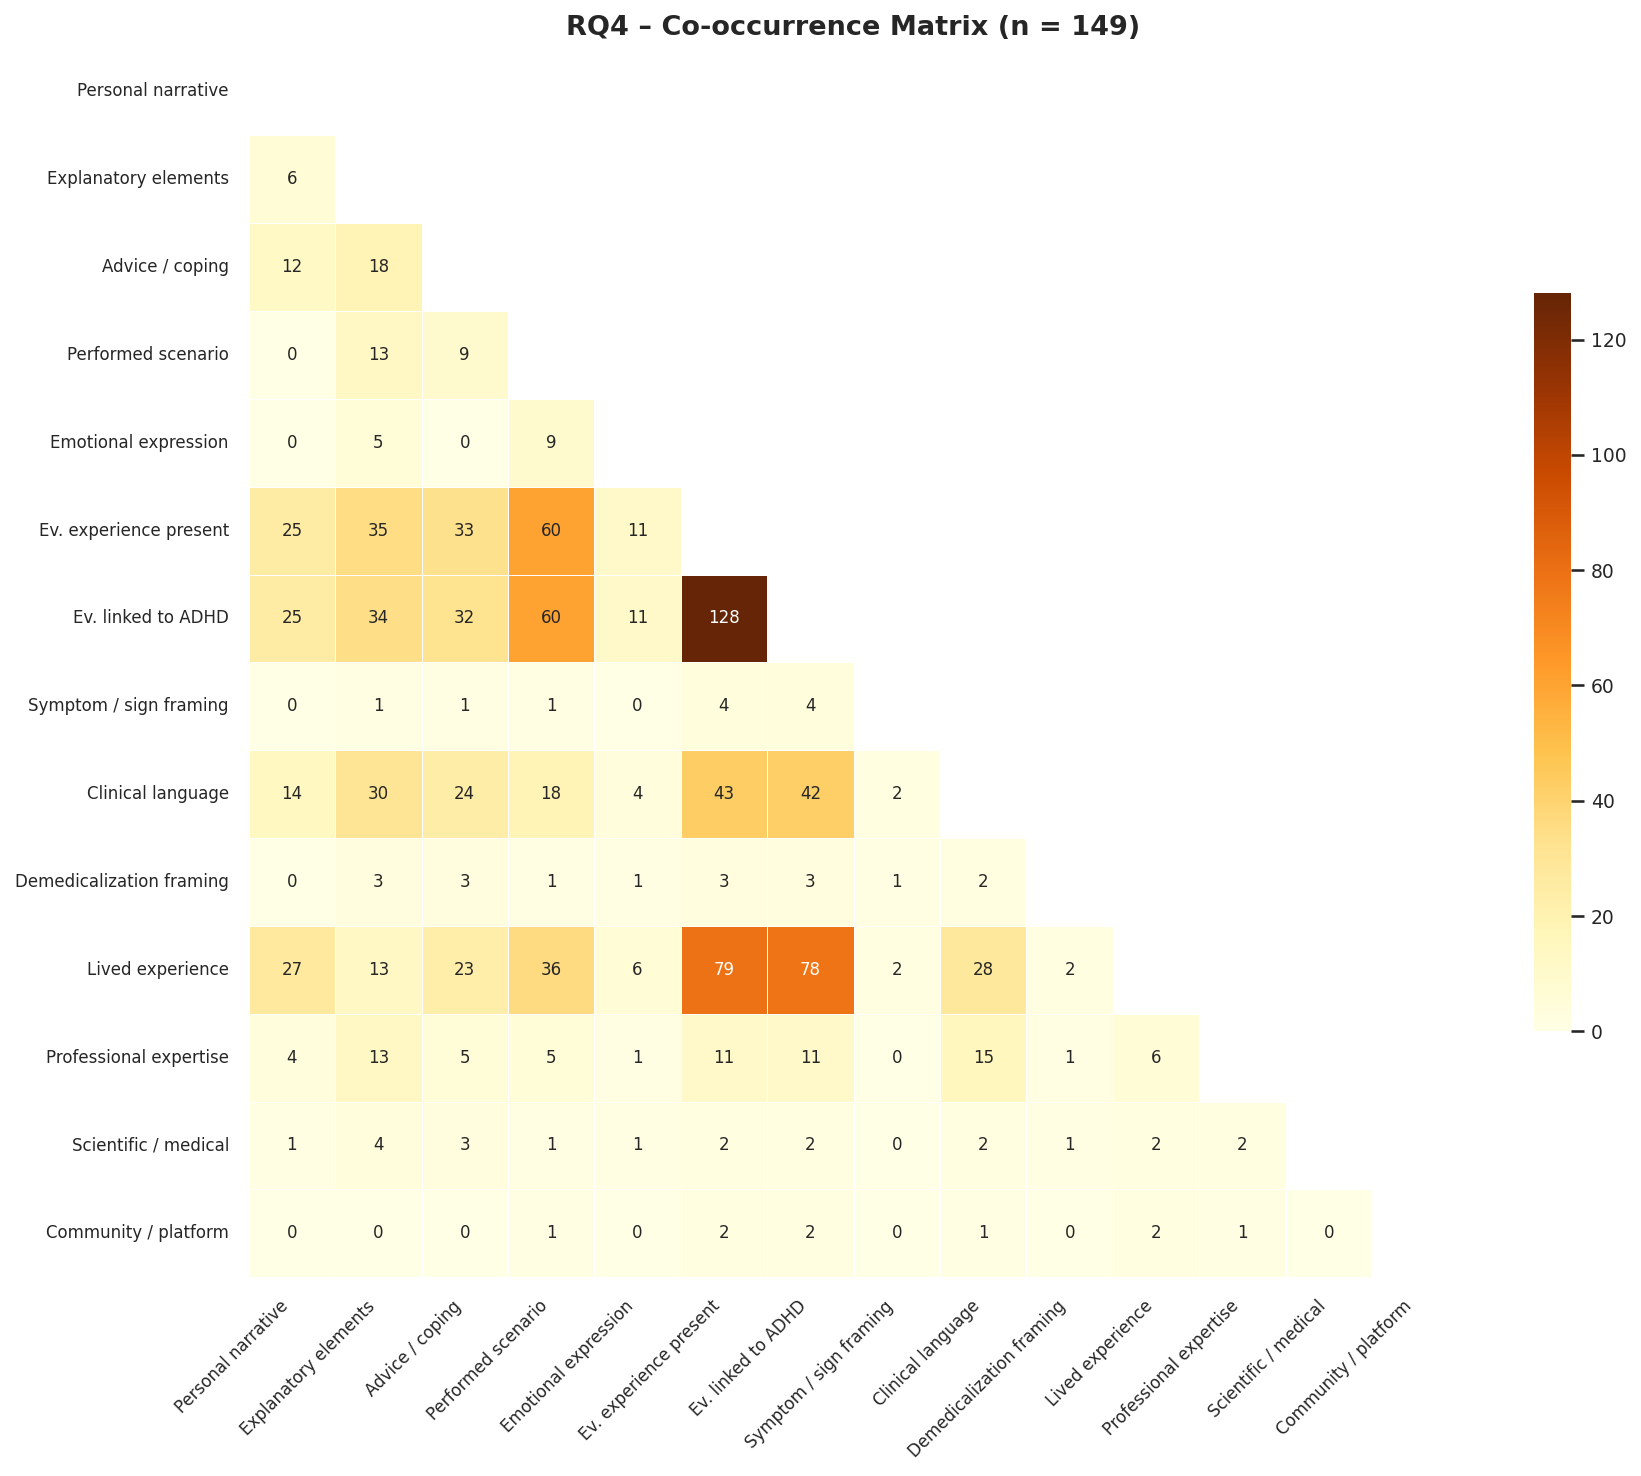

In [14]:
# ── Co-occurrence Heatmap (absolute counts) ───────────────────
data = df[ALL_VARS].astype(int)
cooc = data.T.dot(data)
cooc.index   = [SHORT[v] for v in cooc.index]
cooc.columns = [SHORT[v] for v in cooc.columns]
mask = np.triu(np.ones_like(cooc, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cooc, mask=mask, annot=True, fmt="d", cmap="YlOrBr",
            linewidths=0.4, linecolor="white",
            annot_kws={"size": 8}, ax=ax, cbar_kws={"shrink": 0.6})
ax.set_title(f"RQ4 – Co-occurrence Matrix (n = {N})")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
save("rq4_cooccurrence_abs")
plt.show()

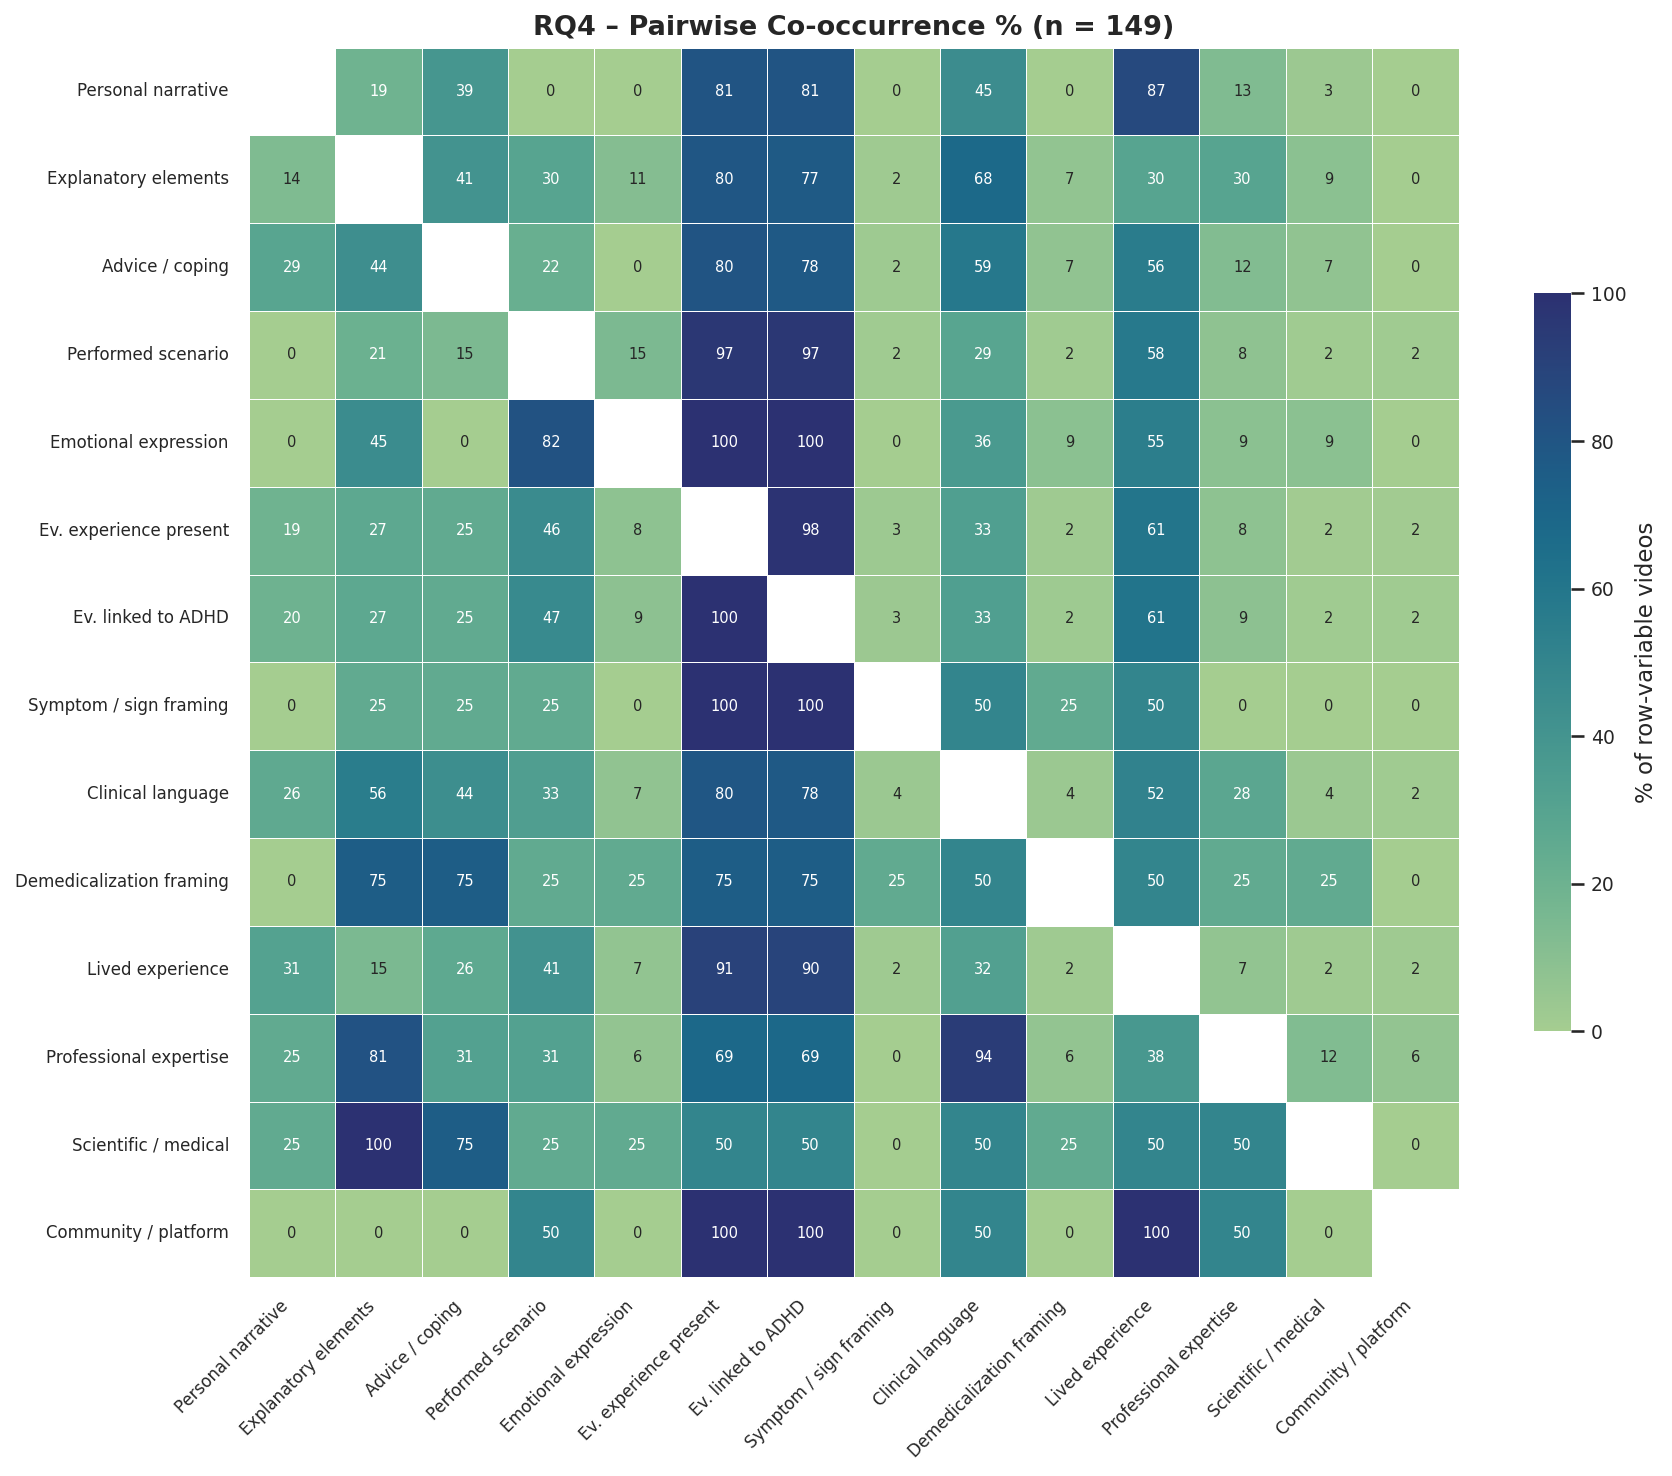

In [15]:
# ── Co-occurrence Heatmap (% of row variable) ────────────────
data = df[ALL_VARS].astype(int)
n_vars = len(ALL_VARS)
pct_matrix = pd.DataFrame(np.zeros((n_vars, n_vars)),
                           index=ALL_VARS, columns=ALL_VARS)
for v1 in ALL_VARS:
    for v2 in ALL_VARS:
        n_v1 = data[v1].sum()
        if n_v1 > 0:
            pct_matrix.loc[v1, v2] = data[(data[v1]==1) & (data[v2]==1)].shape[0] / n_v1 * 100

pct_matrix.index   = [SHORT[v] for v in pct_matrix.index]
pct_matrix.columns = [SHORT[v] for v in pct_matrix.columns]
np.fill_diagonal(pct_matrix.values, np.nan)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pct_matrix, annot=True, fmt=".0f", cmap=CB_SEQ,
            linewidths=0.4, linecolor="white",
            annot_kws={"size": 7}, ax=ax,
            cbar_kws={"label": "% of row-variable videos", "shrink": 0.6})
ax.set_title(f"RQ4 – Pairwise Co-occurrence % (n = {N})")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
save("rq4_cooccurrence_pct")
plt.show()
fig.savefig("cooccurence_heatmap.pdf", bbox_inches="tight", facecolor="white") 

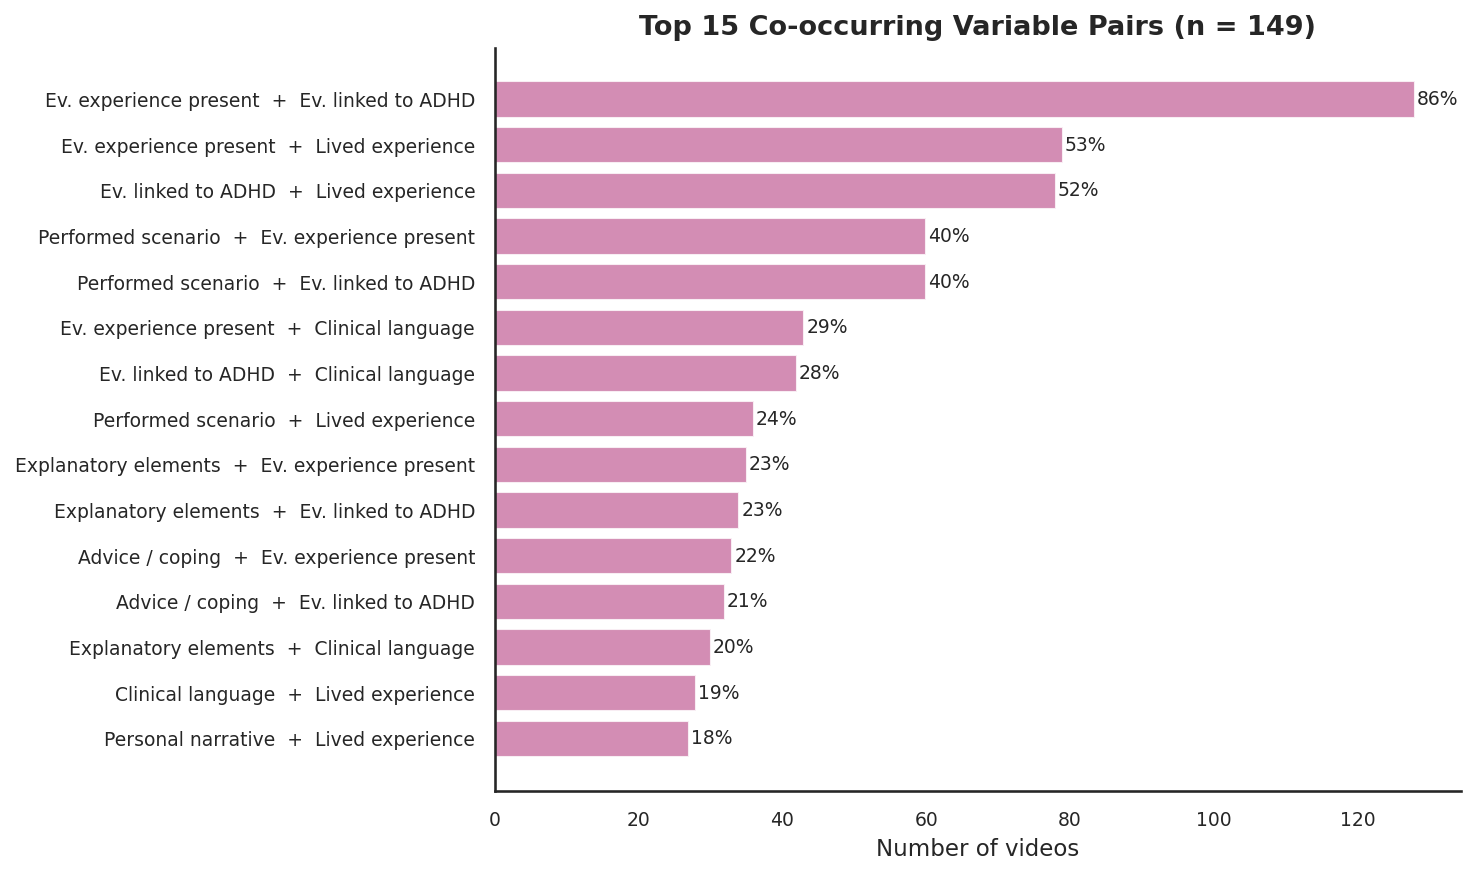

In [16]:
# ── Top Co-occurring Pairs ────────────────────────────────────
data = df[ALL_VARS].astype(int)
pairs = []
for i, v1 in enumerate(ALL_VARS):
    for v2 in ALL_VARS[i+1:]:
        both = int(((data[v1]==1) & (data[v2]==1)).sum())
        if both > 0:
            pairs.append({
                "Pair": f"{SHORT[v1]}  +  {SHORT[v2]}",
                "n": both,
                "%": both / N * 100
            })

pairs_df = pd.DataFrame(pairs).sort_values("n", ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(pairs_df["Pair"], pairs_df["n"], color=PALETTE["RQ4"], alpha=0.85)
for bar, pct in zip(bars, pairs_df["%"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{pct:.0f}%", va="center", fontsize=9)
ax.set_xlabel("Number of videos")
ax.set_title(f"Top 15 Co-occurring Variable Pairs (n = {N})")
plt.tight_layout()
save("rq4_top_pairs")
plt.show()

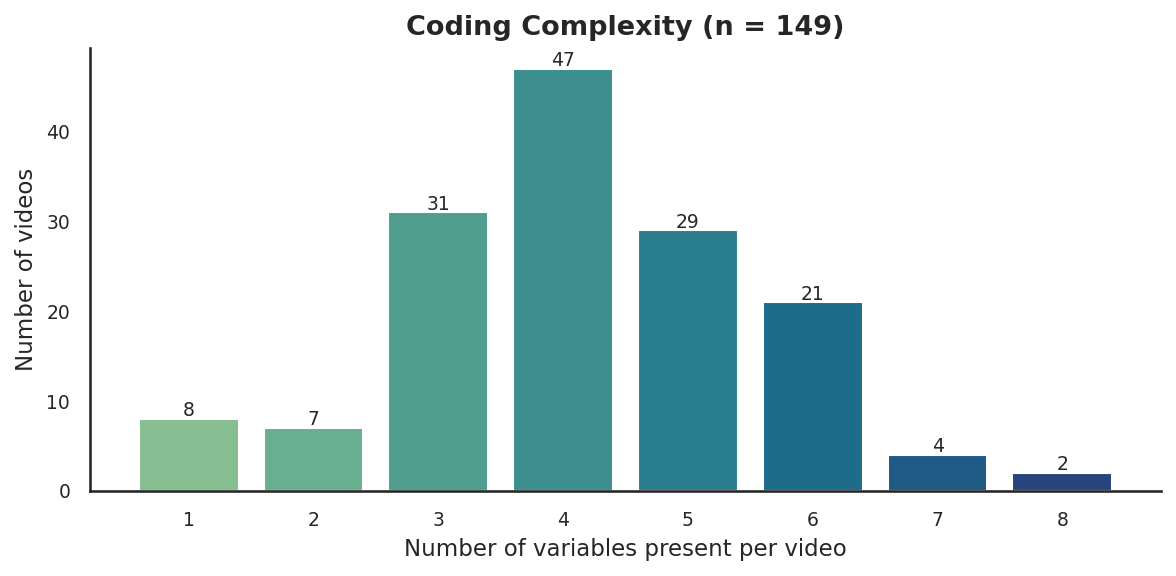

Mean variables per video: 4.1
Median: 4.0


In [17]:
# ── Complexity: Variables per Video ───────────────────────────
df["n_vars"] = df[ALL_VARS].sum(axis=1)
counts = df["n_vars"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(counts.index.astype(str), counts.values,
              color=sns.color_palette(CB_SEQ, len(counts)), edgecolor="white")
ax.set_xlabel("Number of variables present per video")
ax.set_ylabel("Number of videos")
ax.set_title(f"Coding Complexity (n = {N})")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            int(bar.get_height()), ha="center", fontsize=9)
plt.tight_layout()
save("complexity_vars_per_video")
plt.show()
print(f"Mean variables per video: {df['n_vars'].mean():.1f}")
print(f"Median: {df['n_vars'].median():.1f}")

N for Figure 3: 148
Only lived experience: 81 (54.7%)
No identifiable source: 51 (34.5%)
Only professional expertise: 10 (6.8%)
Both sources: 6 (4.1%)


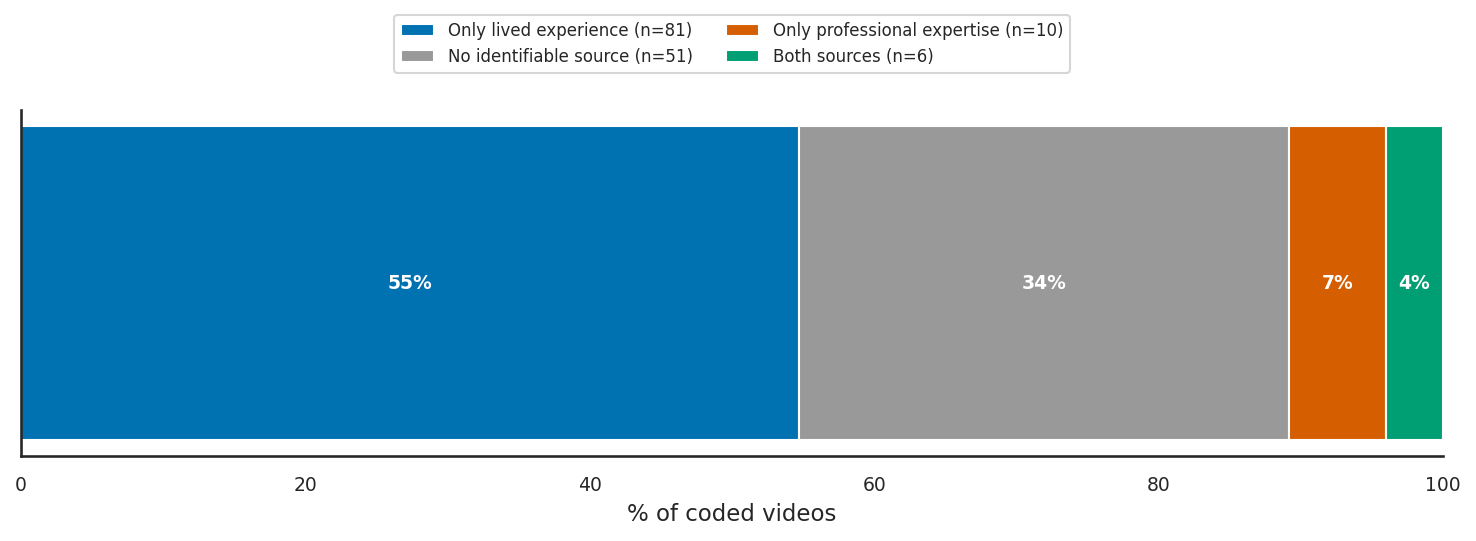

In [18]:
# ── Knowledge Source Distribution (Stacked Bar) ──────────────
# Exclude videos referencing only scientific or community sources (n=1)
df_rq3 = df.copy()
df_rq3['only_sci_or_comm'] = ((df_rq3['lived_experience_source']==0) & (df_rq3['professional_expertise_source']==0) & ((df_rq3['scientific_or_medical_source']==1) | (df_rq3['community_or_platform_source']==1))).astype(int)
df_rq3 = df_rq3[df_rq3['only_sci_or_comm']==0]
N_rq3 = len(df_rq3)

df_rq3['no_source'] = ((df_rq3['lived_experience_source']==0) & (df_rq3['professional_expertise_source']==0) & (df_rq3['scientific_or_medical_source']==0) & (df_rq3['community_or_platform_source']==0)).astype(int)
df_rq3['only_lived'] = ((df_rq3['lived_experience_source']==1) & (df_rq3['professional_expertise_source']==0)).astype(int)
df_rq3['only_prof'] = ((df_rq3['lived_experience_source']==0) & (df_rq3['professional_expertise_source']==1)).astype(int)
df_rq3['both_sources'] = ((df_rq3['lived_experience_source']==1) & (df_rq3['professional_expertise_source']==1)).astype(int)

print(f"N for Figure 3: {N_rq3}")
print(f"Only lived experience: {df_rq3['only_lived'].sum()} ({df_rq3['only_lived'].sum()/N_rq3*100:.1f}%)")
print(f"No identifiable source: {df_rq3['no_source'].sum()} ({df_rq3['no_source'].sum()/N_rq3*100:.1f}%)")
print(f"Only professional expertise: {df_rq3['only_prof'].sum()} ({df_rq3['only_prof'].sum()/N_rq3*100:.1f}%)")
print(f"Both sources: {df_rq3['both_sources'].sum()} ({df_rq3['both_sources'].sum()/N_rq3*100:.1f}%)")

source_data = {
    f"Only lived experience (n={df_rq3['only_lived'].sum()})": df_rq3['only_lived'].sum(),
    f"No identifiable source (n={df_rq3['no_source'].sum()})": df_rq3['no_source'].sum(),
    f"Only professional expertise (n={df_rq3['only_prof'].sum()})": df_rq3['only_prof'].sum(),
    f"Both sources (n={df_rq3['both_sources'].sum()})": df_rq3['both_sources'].sum(),
}

colors = ["#0072B2", "#999999", "#D55E00", "#009E73"]

fig, ax = plt.subplots(figsize=(10, 4))
left = 0
for (label, val), color in zip(source_data.items(), colors):
    pct = val / N_rq3 * 100
    bar = ax.barh(0, pct, left=left, color=color, edgecolor="white", height=0.5)
    if pct > 3:
        ax.text(left + pct/2, 0, f"{pct:.0f}%", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    left += pct

ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel("% of coded videos")
ax.legend(source_data.keys(), loc="upper center", bbox_to_anchor=(0.5, 1.3), ncol=2, fontsize=8)
plt.tight_layout()
fig.savefig("knowledge_source_distribution.pdf", bbox_inches="tight", facecolor="white")
plt.show()

## Chi-Square Tests
Theoretically motivated variable pairs. Bonferroni correction applied for multiple testing.

In [19]:
# ── Chi-Square Tests + Cramér's V ─────────────────────────────
import math

def cramers_v(table):
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    k = min(table.shape) - 1
    return math.sqrt(chi2 / (n * k)) if n * k > 0 else 0

# Two theoretically motivated pairs:
# 1. Does clinical language co-occur with lived experience? (RQ2 x RQ3)
# 2. Does clinical language co-occur with professional expertise? (RQ2 x RQ3)
test_pairs = [
    ("clinical_or_diagnostic_language", "lived_experience_source"),
    ("clinical_or_diagnostic_language", "professional_expertise_source"),
]

n_tests = len(test_pairs)
alpha = 0.05
alpha_corrected = alpha / n_tests

results = []
for v1, v2 in test_pairs:
    table = pd.crosstab(df[v1], df[v2])
    chi2, p, dof, expected = chi2_contingency(table)
    min_expected = expected.min()
    if min_expected < 5:
        if table.shape == (2, 2):
            odds, p_fisher = fisher_exact(table)
            results.append({
                "Pair": f"{SHORT[v1]}  +  {SHORT[v2]}",
                "Test": "Fisher's exact",
                "p-value": f"{p_fisher:.4f}",
                "Significant (Bonferroni)": "Yes" if p_fisher < alpha_corrected else "No",
                "Cramér's V": f"{cramers_v(table):.3f}",
                "Min expected freq.": f"{min_expected:.1f}"
            })
        else:
            results.append({
                "Pair": f"{SHORT[v1]}  +  {SHORT[v2]}",
                "Test": "Chi-square (warning: low expected)",
                "p-value": f"{p:.4f}",
                "Significant (Bonferroni)": "Yes" if p < alpha_corrected else "No",
                "Cramér's V": f"{cramers_v(table):.3f}",
                "Min expected freq.": f"{min_expected:.1f}"
            })
    else:
        results.append({
            "Pair": f"{SHORT[v1]}  +  {SHORT[v2]}",
            "Test": "Chi-square",
            "p-value": f"{p:.4f}",
            "Significant (Bonferroni)": "Yes" if p < alpha_corrected else "No",
            "Cramér's V": f"{cramers_v(table):.3f}",
            "Min expected freq.": f"{min_expected:.1f}"
        })

print(f"Bonferroni-corrected alpha: {alpha_corrected:.4f} (alpha={alpha}, n_tests={n_tests})")
display(pd.DataFrame(results))

Bonferroni-corrected alpha: 0.0250 (alpha=0.05, n_tests=2)


,Pair,Test,p-value,Significant (Bonferroni),Cramér's V,Min expected freq.
0,Clinical language + Lived experience,Chi-square,0.2948,No,0.086,22.5
1,Clinical language + Professional expertise,Chi-square,0.0000,Yes,0.392,5.8
